<h1 style="text-align: center; color: #2E8B57; font-family: 'Arial', sans-serif; margin-top: 50px;">
  <span style="font-size: 48px; font-weight: bold;">🌱 AI-Powered Plant Disease Detection</span><br>
  <span style="font-size: 36px;">& Fertilizer Recommendation System</span>
</h1>

---

**Dataset:** https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

## Import Libraries

In this section, we are importing all the necessary libraries and modules like PyTorch, torchvision, PIL, etc., which we will use to handle datasets, build models, and perform data processing.

In [1]:
import os
import gc
import torch
from PIL import Image
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import figure
from torchvision.utils import make_grid
from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

## Dataset Overview

Let's explore the dataset by listing the folder contents and checking the number of images in each class. This will help us understand the structure of our dataset.

In [2]:
folder_path = r'D:\play\rice_leaf_diseases'

file_list = os.listdir(folder_path)
file_list

['Bacterial leaf blight',
 'Brown spot',
 'Leaf smut',
 'plant_disease_dataset.csv',
 'Plant_Disease_Detection_Model.pth',
 'test']

In [3]:
for cls in file_list:
  print(cls, ':', len(os.listdir(folder_path  + '/' + cls)))

Bacterial leaf blight : 40
Brown spot : 40
Leaf smut : 40


NotADirectoryError: [WinError 267] The directory name is invalid: 'D:\\play\\rice_leaf_diseases/plant_disease_dataset.csv'

## Transforming and Preparing the Dataset

Here, we are applying transformations like resizing and cropping to the images. These transformations will ensure uniformity and improve training efficiency.

In [4]:
dataset = ImageFolder(folder_path, transform = tt.Compose([tt.Resize(255), tt.RandomCrop(224), tt.ToTensor()]))

In [5]:
dataset

Dataset ImageFolder
    Number of datapoints: 153
    Root location: D:\play\rice_leaf_diseases
    StandardTransform
Transform: Compose(
               Resize(size=255, interpolation=bilinear, max_size=None, antialias=True)
               RandomCrop(size=(224, 224), padding=None)
               ToTensor()
           )

## Visualizing Sample Images

In this section, we visualize a few sample images to understand the dataset better and ensure the transformations are correctly applied.

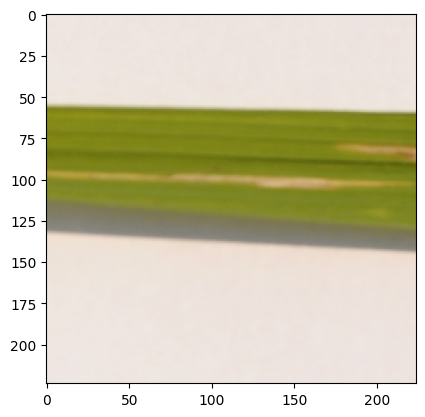

In [6]:
image, label = dataset[14]
plt.imshow(image.permute(1,2,0))

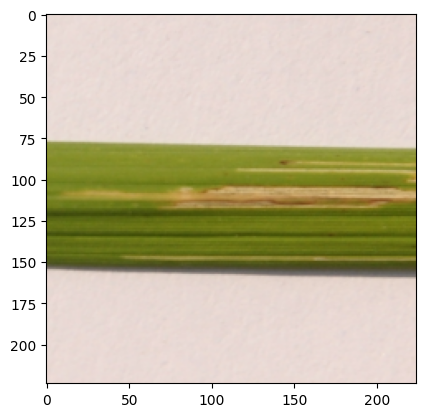

In [7]:
image, label = dataset[15]
plt.imshow(image.permute(1,2,0))

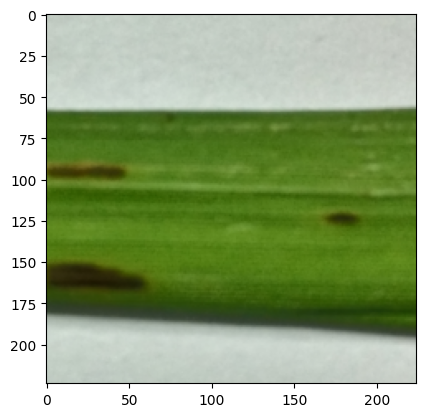

In [8]:
image, label = dataset[111]
plt.imshow(image.permute(1,2,0))

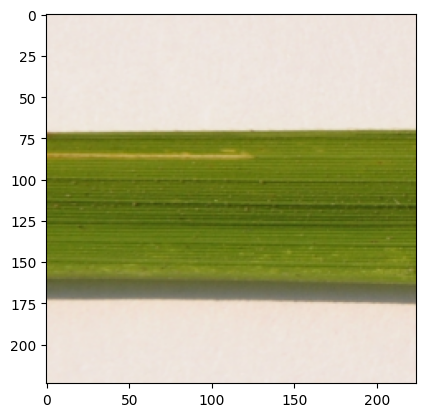

In [9]:
image, label = dataset[24]
plt.imshow(image.permute(1,2,0))

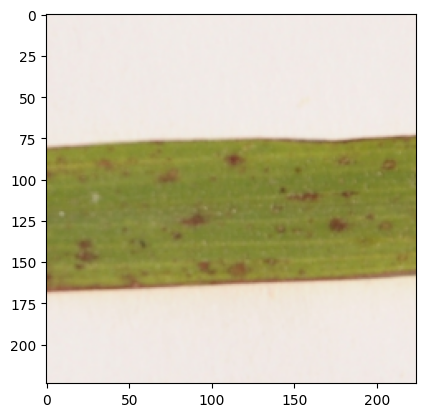

In [10]:
image, label = dataset[84]
plt.imshow(image.permute(1,2,0))

## Splitting the Dataset

We split the dataset into training and validation sets, ensuring that we can evaluate our model's performance during training.

In [11]:
size_per = 0.2
valid_size = int(len(dataset) * size_per)
train_size = len(dataset) - valid_size

train_ds, valid_ds = random_split(dataset, [train_size, valid_size])
print("Length of Train dataset :",len(train_ds))
print("Length of Valid dataset :",len(valid_ds))

Length of Train dataset : 123
Length of Valid dataset : 30


### Creating DataLoaders

DataLoaders are created to load the data in batches for efficient training and validation.

In [12]:
batch_size = 64
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=4, pin_memory=True)
valid_dl = DataLoader(valid_ds, batch_size, num_workers=4, pin_memory=True)

### Visualizing Batch of Images

Let's display a batch of images from the training DataLoader to ensure the batches are being created correctly.

In [13]:
def show_batch(dl):
  for image, _ in dl:
    px, ax = plt.subplots(figsize=(16,12))
    ax.set_xticks([]), ax.set_yticks([])
    ax.imshow(make_grid(image, nrow=16).permute(1,2,0))
    torch.cuda.empty_cache
    break


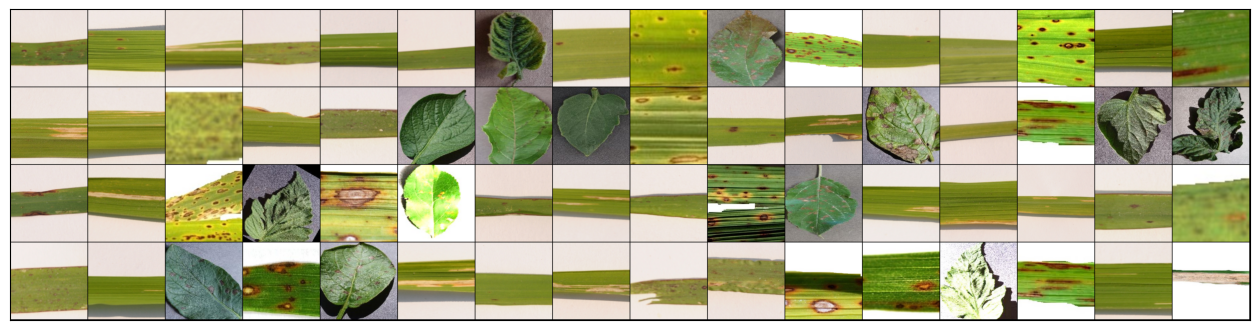

In [14]:
show_batch(train_dl)

We define utility functions to move data and DataLoaders to the GPU if available, speeding up the computations.

In [17]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)


In [18]:
device = get_default_device()
device

device(type='cpu')

In [19]:
train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(valid_dl, device)

## Building the **CNN** Model

Here, we define our CNN model structure, including convolutional layers, pooling, and fully connected layers, for plant disease detection.

In [20]:
class PlantDiseaseDetection(nn.Module):
    """ calculate the loss of batch of training dataloader"""
    def training_step(self, batch):
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        torch.cuda.empty_cache
        return loss
    """calculate the loss and accuracy of batch of validation dataloader"""
    def validation_step(self, batch):
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)
        torch.cuda.empty_cache          # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))


In [21]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

@torch.no_grad()
def evaluate(model, val_loader):
    """ Define the model's performance on validation set..."""
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):

        # Training Phase
        model.train()
        train_losses = []
        for batch in train_loader:
            torch.cuda.empty_cache
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            torch.cuda.empty_cache

        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
        torch.cuda.empty_cache
    return history

In [22]:
class CNN(PlantDiseaseDetection):
    def __init__(self, K):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            # conv1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            # conv2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            # conv3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            # conv4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )

        self.dense_layers = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(50176, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, K),
        )

    def forward(self, X):
        out = self.conv_layers(X)

        # Flatten
        out = out.view(-1, 50176)

        # Fully connected
        out = self.dense_layers(out)

        return out

In [23]:
model = to_device(CNN(len(dataset.classes)), device)
model

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [24]:
torch.cuda.empty_cache
for batch in train_dl:
  images, labels = batch
  print("images_shape:", images.shape)
  print("image_device:", images.device)
  pred = model(images)
  print('pred_shape:', pred.shape)
  torch.cuda.empty_cache
  break

images_shape: torch.Size([64, 3, 224, 224])
image_device: cpu
pred_shape: torch.Size([64, 4])


In [25]:
history = [evaluate(model, valid_dl)]
history

[{'val_loss': 1.3863987922668457, 'val_acc': 0.23333333432674408}]

### Training the Model

In this section, we train the CNN model for several epochs and record the training and validation losses and accuracies.

In [26]:
%%time
history += fit(5, 0.001, model, train_dl, valid_dl, torch.optim.Adam)

Epoch [0], train_loss: 12.0600, val_loss: 3.5164, val_acc: 0.2667
Epoch [1], train_loss: 18.1995, val_loss: 9.0663, val_acc: 0.2333
Epoch [2], train_loss: 11.3130, val_loss: 9.4647, val_acc: 0.2667
Epoch [3], train_loss: 5.3453, val_loss: 28.2822, val_acc: 0.2667
Epoch [4], train_loss: 3.3102, val_loss: 27.4917, val_acc: 0.2667
CPU times: total: 5min 39s
Wall time: 2min 36s


In [27]:
%%time
history += fit(5, 0.0001, model, train_dl, valid_dl, torch.optim.Adam)

Epoch [0], train_loss: 1.7883, val_loss: 25.0571, val_acc: 0.2667
Epoch [1], train_loss: 1.2850, val_loss: 23.1474, val_acc: 0.2667
Epoch [2], train_loss: 1.8737, val_loss: 20.9393, val_acc: 0.2667
Epoch [3], train_loss: 0.6514, val_loss: 19.4431, val_acc: 0.2667
Epoch [4], train_loss: 1.1907, val_loss: 18.0730, val_acc: 0.2667
CPU times: total: 5min 19s
Wall time: 2min 31s


In [28]:
%%time
history += fit(5, 0.00001, model, train_dl, valid_dl, torch.optim.Adam)

Epoch [0], train_loss: 0.6812, val_loss: 18.8920, val_acc: 0.3000
Epoch [1], train_loss: 0.7820, val_loss: 19.4836, val_acc: 0.2667
Epoch [2], train_loss: 0.8701, val_loss: 19.8400, val_acc: 0.3333
Epoch [3], train_loss: 0.7124, val_loss: 19.5551, val_acc: 0.4667
Epoch [4], train_loss: 0.7468, val_loss: 19.2087, val_acc: 0.4333
CPU times: total: 5min 16s
Wall time: 2min 30s


In [29]:
%%time
history += fit(5, 0.000001, model, train_dl, valid_dl, torch.optim.Adam)

Epoch [0], train_loss: 0.5394, val_loss: 18.4395, val_acc: 0.3333
Epoch [1], train_loss: 0.5654, val_loss: 17.1787, val_acc: 0.3667
Epoch [2], train_loss: 0.5829, val_loss: 16.0898, val_acc: 0.4333
Epoch [3], train_loss: 0.4150, val_loss: 14.8188, val_acc: 0.4000
Epoch [4], train_loss: 0.8149, val_loss: 14.1699, val_acc: 0.4667
CPU times: total: 5min 27s
Wall time: 22min 39s


In [30]:
%%time
history += fit(10, 0.0000001, model, train_dl, valid_dl, torch.optim.Adam)

Epoch [0], train_loss: 0.4973, val_loss: 13.0043, val_acc: 0.3667
Epoch [1], train_loss: 0.7928, val_loss: 11.5098, val_acc: 0.4667
Epoch [2], train_loss: 0.7028, val_loss: 10.6464, val_acc: 0.4000
Epoch [3], train_loss: 0.5915, val_loss: 9.2121, val_acc: 0.3667
Epoch [4], train_loss: 0.4570, val_loss: 7.3179, val_acc: 0.4333
Epoch [5], train_loss: 0.3668, val_loss: 6.1779, val_acc: 0.4333
Epoch [6], train_loss: 0.5512, val_loss: 5.1003, val_acc: 0.5333
Epoch [7], train_loss: 0.5051, val_loss: 4.0173, val_acc: 0.6333
Epoch [8], train_loss: 0.7480, val_loss: 2.8765, val_acc: 0.7000
Epoch [9], train_loss: 0.5875, val_loss: 3.4676, val_acc: 0.7000
CPU times: total: 9min 52s
Wall time: 4min 28s


**CNN Accuracy: 97.59%**

### Saving the Model

Save the trained model to the Kaggle working directory for future use or deployment.

In [31]:
torch.save(model.state_dict(), 'Plant_Disease_Detection_Model.pth')


In [33]:
# Display confirmation

#print(f"Model saved to: {model_path}")

In [34]:
import torch

targets_size = 3
model = CNN(targets_size)

model_path = r'D:\play\rice_leaf_diseases\Plant_Disease_Detection_Model.pth'  # Correct local path

# Check if CUDA is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model to appropriate device
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)  # Ensure model is moved to the correct device
model.eval()

print(f"Model successfully loaded on {device} and ready for evaluation.")


Model successfully loaded on cpu and ready for evaluation.


### Plotting Accuracy and Loss

Finally, we visualize the training and validation accuracy and loss over the epochs to understand the model's performance trends.

In [43]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

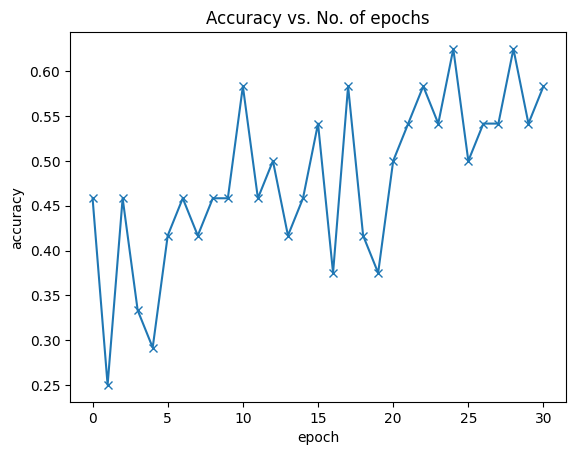

In [44]:
plot_accuracies(history)

In [45]:
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

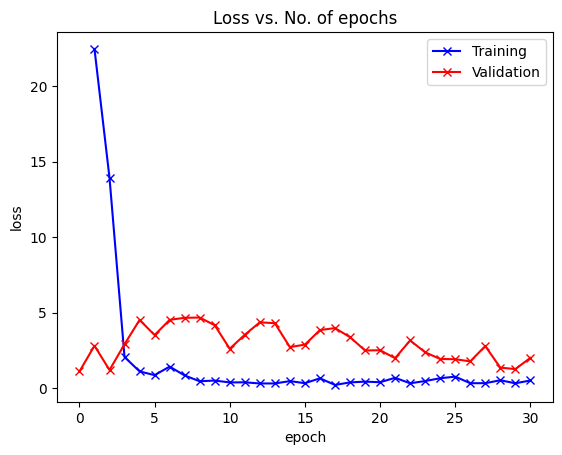

In [46]:
plot_losses(history)

## Predicting Plant Diseases Using the Model

This section demonstrates how to use the trained CNN model to predict plant diseases for individual images and obtain detailed information about the crop and disease.

In [47]:
model = to_device(model, device)

### Predict Disease from a Single Image

We define a helper function, predict_image, to process and predict the disease category of an image using the trained model. The predicted result is matched with the corresponding class name.

In [48]:
def predict_image(img, model):
    xb = to_device(img.unsqueeze(0), device)
    yb = model(xb)
    _, preds  = torch.max(yb, dim=1)
    return dataset.classes[preds[0].item()]

In [49]:
def show_image_prediction(img, label):
  plt.imshow(img.permute(1, 2, 0))
  print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

In [51]:
print(len(valid_ds))  # Check dataset size


24


Label: Bacterial leaf blight , Predicted: Brown spot


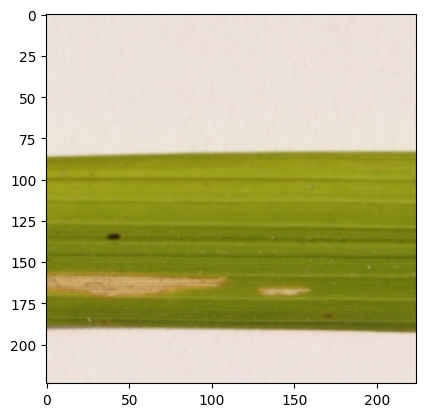

In [52]:
show_image_prediction(*valid_ds[23])  # Access last sample (index 23)


Label: Bacterial leaf blight , Predicted: Brown spot


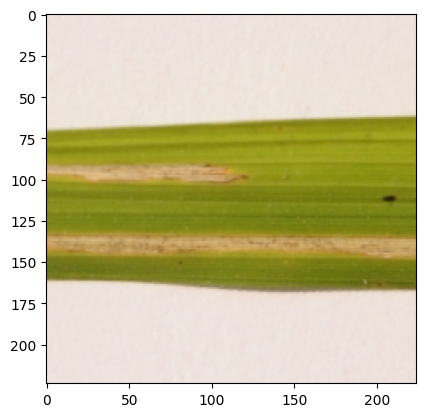

In [53]:
show_image_prediction(*valid_ds[23])

Label: Bacterial leaf blight , Predicted: Bacterial leaf blight


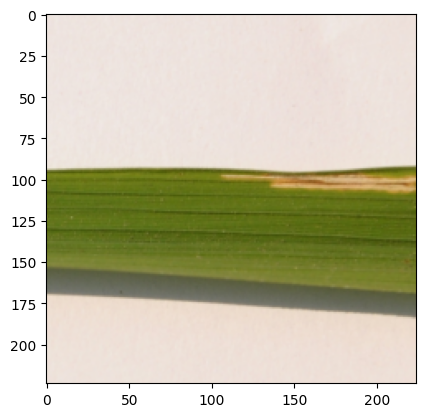

In [54]:
show_image_prediction(*valid_ds[22])

---

### Detailed Prediction with Supplementary Information

To provide more context about the predictions, we use an external dataset that maps class indices to crop names and diseases. The single_prediction function predicts the disease for a given image and extracts additional details.

In [56]:
supplement_info = pd.read_csv("D:\play\AI-Powered-Plant-Disease-Detection-and-Fertilizer-Recommendation-System-main\supplement_info.csv")

In [57]:
supplement_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   index             39 non-null     int64 
 1   disease_name      39 non-null     object
 2   supplement name   38 non-null     object
 3   supplement image  38 non-null     object
 4   buy link          38 non-null     object
dtypes: int64(1), object(4)
memory usage: 1.6+ KB


In [58]:
# Function for prediction

def single_prediction(image_path):
    image = Image.open(image_path)
    image = image.resize((224, 224))
    input_data = TF.to_tensor(image)
    input_data = input_data.unsqueeze(0).to(device)

    output = model(input_data)
    output = output.detach().cpu().numpy()
    index = np.argmax(output)

    predicted_class_name = supplement_info["disease_name"][index]
    crop, disease = predicted_class_name.split('___')

    print(f"Original :  {predicted_class_name}")
    print(f"{crop} : {disease}")

In [59]:
model.to(device)
model.eval()

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [60]:
single_prediction("/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___Early_blight/004cbe60-8ff9-4965-92df-e86694d5e9ba___RS_Erly.B 8253.JPG")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___Early_blight/004cbe60-8ff9-4965-92df-e86694d5e9ba___RS_Erly.B 8253.JPG'

In [ ]:
single_prediction("/kaggle/input/new-plant-diseases-dataset/test/test/AppleCedarRust1.JPG")

In [ ]:
single_prediction("/kaggle/input/new-plant-diseases-dataset/test/test/AppleCedarRust1.JPG")

In [ ]:
single_prediction("/kaggle/input/new-plant-diseases-dataset/test/test/TomatoHealthy3.JPG")

In [ ]:
single_prediction("/kaggle/input/new-plant-diseases-dataset/test/test/TomatoEarlyBlight6.JPG")

In [ ]:
single_prediction("/kaggle/input/new-plant-diseases-dataset/test/test/PotatoEarlyBlight4.JPG")

In [ ]:
single_prediction("/kaggle/input/new-plant-diseases-dataset/test/test/AppleScab1.JPG")

---
---

### **Conclusion and Future Goals**

The AI-Powered Plant Disease Detection and Fertilizer Recommendation System successfully demonstrates the integration of deep learning and rule-based techniques to address agricultural challenges. Using a CNN-based model, the system accurately identifies plant diseases, providing actionable insights for farmers and agricultural stakeholders. The rule-based module complements this by recommending suitable fertilizers, ensuring healthier crop growth. The user-friendly interface designed with Flask further enhances accessibility for end users, making the solution practical for real-world deployment.  

**Future Goals:**  
- Extend the system's functionality to support more crops and diseases for broader applicability.  
- Develop a mobile application to improve portability and usability in field conditions.  
- Incorporate real-time disease monitoring using live camera feeds.  
- Enhance the fertilizer recommendation module by integrating dynamic, region-specific soil and weather data.  
- Implement predictive analytics for early disease detection and prevention.  
- Transition to a cloud-based solution for scalable processing of large datasets.  
- Collaborate with agricultural experts to validate and refine the system's accuracy and effectiveness.  